<a href="https://colab.research.google.com/github/DarthRelkew/DS450/blob/main/copy_of_starter_bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
campaign = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv')

# import polars as pl
# campaign = pl.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv', schema_overrides={'nr.employed': pl.Float64})

In [ ]:
display(
    campaign.head(),
    campaign.describe(),

)
campaign.info()
campaign.columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000
mean,40.025493,2.564407,962.221803,0.173730,0.081526,93.576551,-40.494829,3.621945,5167.010650
std,10.435288,2.764084,187.531477,0.496159,1.572287,0.579339,4.628895,1.734496,72.294476
min,17.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37069 entries, 0 to 37068
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             37069 non-null  int64  
 1   job             37069 non-null  object 
 2   marital         37069 non-null  object 
 3   education       37069 non-null  object 
 4   default         37069 non-null  object 
 5   housing         37069 non-null  object 
 6   loan            37069 non-null  object 
 7   contact         37069 non-null  object 
 8   month           37069 non-null  object 
 9   day_of_week     37069 non-null  object 
 10  campaign        37069 non-null  int64  
 11  pdays           37069 non-null  int64  
 12  previous        37069 non-null  int64  
 13  poutcome        37069 non-null  object 
 14  emp.var.rate    37069 non-null  float64
 15  cons.price.idx  37069 non-null  float64
 16  cons.conf.idx   37069 non-null  float64
 17  euribor3m       37069 non-null 

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [ ]:
campaign["y"].value_counts()

,count
y,
no,32861
yes,4208


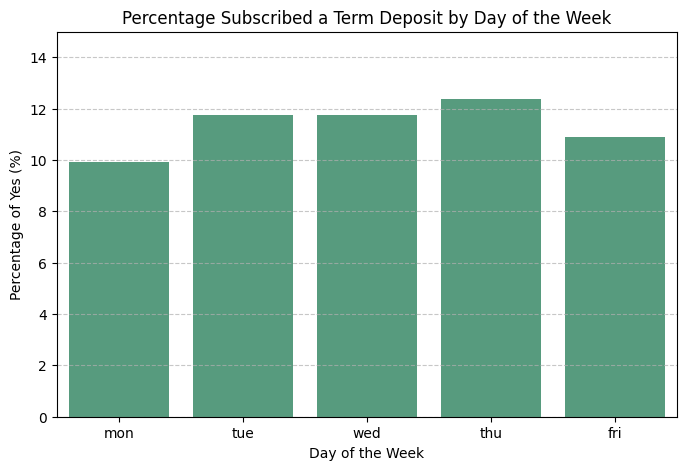

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate percentages of 'y' (yes/no) for each day of the week
day_y_pct = (
    campaign.groupby('day_of_week')['y']
    .value_counts(normalize=True)
    .rename('percentage')
    .mul(100)
    .reset_index()
)

# Filter to only keep the 'yes' responses
day_yes_pct = day_y_pct[day_y_pct['y'] == 'yes']

# Order the days of the week logically
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']

# Create a bar plot to compare the 'yes' percentages
plt.figure(figsize=(8, 5))
sns.barplot(
    data=day_yes_pct,
    x='day_of_week',
    y='percentage',
    order=day_order,
    color='#4ca680'
)

plt.title('Percentage Subscribed a Term Deposit by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Percentage of Yes (%)')
plt.ylim(0, 15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

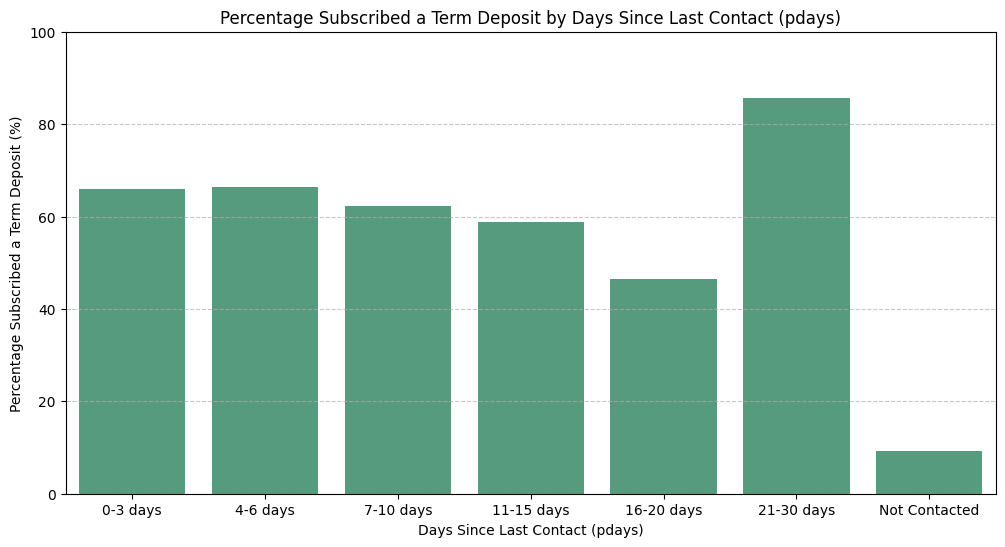

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a working copy of the dataset
campaign_pdays = campaign.copy()

# Define bins and labels for contacted clients
bins = [0, 3, 6, 10, 15, 20, 30]
labels = ['0-3 days', '4-6 days', '7-10 days', '11-15 days', '16-20 days', '21-30 days']

# Bin the contacted clients first
campaign_pdays['pdays_bin'] = pd.cut(campaign_pdays['pdays'], bins=bins, labels=labels, include_lowest=True)

# Convert to string to easily append the non-contacted category
campaign_pdays['pdays_bin'] = campaign_pdays['pdays_bin'].astype(str)

# Assign 'Not Contacted' to the 999 value
campaign_pdays.loc[campaign_pdays['pdays'] == 999, 'pdays_bin'] = 'Not Contacted'

# Calculate the percentage of 'yes' responses in each bin
bin_y_pct = (
    campaign_pdays.groupby('pdays_bin')['y']
    .value_counts(normalize=True)
    .rename('percentage')
    .mul(100)
    .reset_index()
)

# Filter to only keep the 'yes' responses
bin_yes_pct = bin_y_pct[bin_y_pct['y'] == 'yes']

# Order the bins logically with 'Not Contacted' at the end
bin_order = labels + ['Not Contacted']

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=bin_yes_pct,
    x='pdays_bin',
    y='percentage',
    order=bin_order,
    color='#4ca680'
)

plt.title('Percentage Subscribed a Term Deposit by Days Since Last Contact (pdays)')
plt.xlabel('Days Since Last Contact (pdays)')
plt.ylabel('Percentage Subscribed a Term Deposit (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

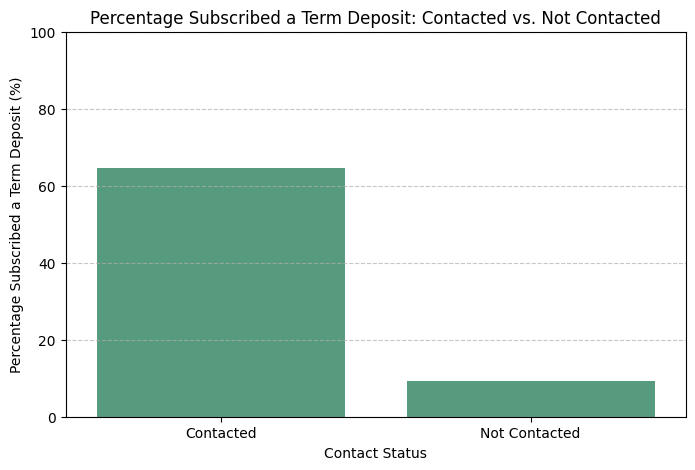

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a working copy of the dataset
campaign_contact = campaign.copy()

# Create a new column indicating whether the client was contacted or not
campaign_contact['contact_status'] = campaign_contact['pdays'].apply(
    lambda x: 'Not Contacted' if x == 999 else 'Contacted'
)

# Calculate the percentage of 'yes' responses for each contact status
contact_y_pct = (
    campaign_contact.groupby('contact_status')['y']
    .value_counts(normalize=True)
    .rename('percentage')
    .mul(100)
    .reset_index()
)

# Filter to only keep the 'yes' responses
contact_yes_pct = contact_y_pct[contact_y_pct['y'] == 'yes']

# Create a bar plot comparing Contacted vs Not Contacted
plt.figure(figsize=(8, 5))
sns.barplot(
    data=contact_yes_pct,
    x='contact_status',
    y='percentage',
    order=['Contacted', 'Not Contacted'],
    color='#4ca680'
)

plt.title('Percentage Subscribed a Term Deposit: Contacted vs. Not Contacted')
plt.xlabel('Contact Status')
plt.ylabel('Percentage Subscribed a Term Deposit (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

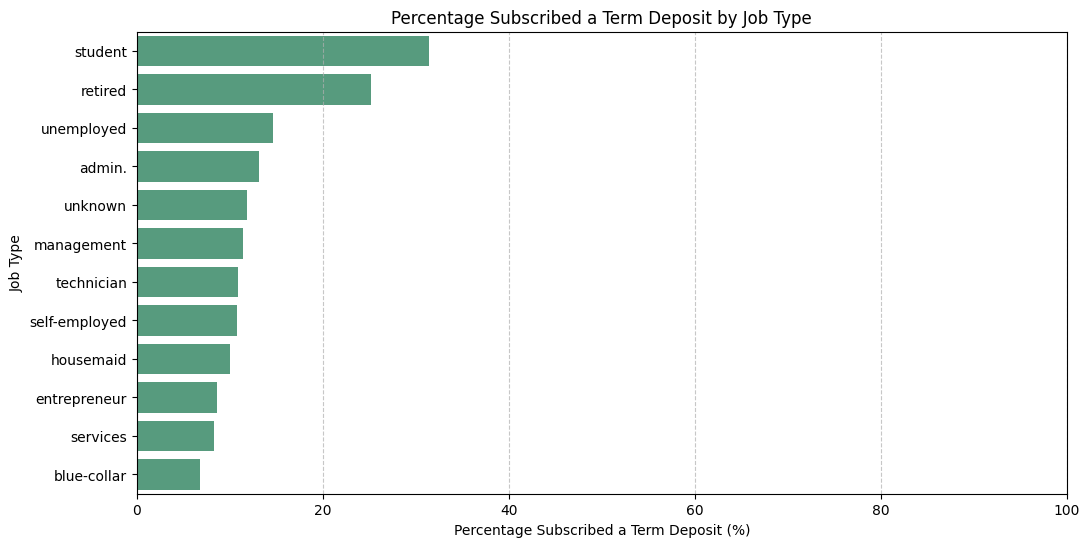

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate percentages of 'y' (yes/no) for each job type
job_y_pct = (
    campaign.groupby('job')['y']
    .value_counts(normalize=True)
    .rename('percentage')
    .mul(100)
    .reset_index()
)

# Filter to only keep the 'yes' responses
job_yes_pct = job_y_pct[job_y_pct['y'] == 'yes']

# Sort by percentage in descending order for better visualization
job_order = job_yes_pct.sort_values('percentage', ascending=False)['job'].tolist()

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=job_yes_pct,
    x='percentage',
    y='job',
    order=job_order,
    color='#4ca680'
)

plt.title('Percentage Subscribed a Term Deposit by Job Type')
plt.xlabel('Percentage Subscribed a Term Deposit (%)')
plt.ylabel('Job Type')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Predictive Modeling: 80/20 Train-Test Split
In this section, we will prepare the dataset by encoding categorical variables and training a Machine Learning model (Random Forest Classifier) using an 80% training and 20% testing split.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# Create a copy for modeling
model_df = campaign.copy()

# Encode categorical variables using LabelEncoder
# Note: For production models, One-Hot Encoding is often preferred, but Label Encoding is perfect for tree-based models like Random Forest.
label_encoders = {}
for column in model_df.select_dtypes(include=['object']).columns:
    if column != 'y':
        le = LabelEncoder()
        model_df[column] = le.fit_transform(model_df[column].astype(str))
        label_encoders[column] = le

# Map the target variable 'y' to 1 for yes and 0 for no
model_df['y'] = model_df['y'].map({'yes': 1, 'no': 0})

# Separate features (X) and target variable (y)
X = model_df.drop(columns=['y'])
y = model_df['y']

# Perform 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Initialize and train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Make predictions on test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance Analysis
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top Feature Importances:")
print(importances.head(10))

Model Accuracy: 89.72%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      6572
           1       0.59      0.31      0.40       842

    accuracy                           0.90      7414
   macro avg       0.75      0.64      0.67      7414
weighted avg       0.88      0.90      0.88      7414

Top Feature Importances:
age             0.164207
euribor3m       0.149458
campaign        0.083192
job             0.080904
education       0.074958
nr.employed     0.073400
day_of_week     0.059533
emp.var.rate    0.051311
marital         0.039245
housing         0.032377
dtype: float64
